In [1]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv(
    "RAG_Context_Adherence_And_Hallucination_Benchmark.csv"
)

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully!
Rows: 30000
Columns: 18


In [3]:
df.head()

,Interaction_ID,User_Prompt,Provided_Context,LLM_Generated_Response,LLM_Model_Name,Temperature_Setting,Vector_DB_Similarity_Score,Prompt_Tokens,Response_Tokens,Context_Response_Overlap_Ratio,Entity_Match_Score,Sentence_Complexity_Index,Subjectivity_Score,Contradiction_Words_Count,Answer_Relevance_Score,Context_Faithfulness_Score,Hallucination_Type,Is_Hallucination
0,INT_000001,Compare the growth rates of Advanced Computing...,Advanced Computing is a Technology company fou...,The company uses IoT sensors as its primary te...,Mistral-7B,0.02,0.614,90,13,0.062,0.000,0.372,0.500,0,0.547,0.671,Fabrication,1
1,INT_000002,By what percentage did {organization}'s revenu...,Iota Logistics is a Healthcare company founded...,"Iota Logistics reported revenue of $1,069,876,...",Mistral-7B,0.51,0.623,86,11,0.140,0.143,0.321,0.000,0,0.570,0.388,Fabrication,1
2,INT_000003,What was {organization}'s revenue in 2024?,Apex Dynamics is a Sports company founded in 2...,"Actually, the revenue was $1,888,588,571, not ...",Mistral-7B,0.06,0.040,85,13,0.042,0.000,0.344,0.133,0,0.593,0.318,Contradiction,1
3,INT_000004,What is {organization}'s main product?,Vertex Systems is a Sports company founded in ...,Vertex Systems was founded in 2002 and is head...,GPT-4o,0.47,0.217,86,19,0.235,0.286,0.323,0.455,0,0.827,0.819,NaN,0
4,INT_000005,Which organization has the highest growth rate...,Advanced Green is a Energy company founded in ...,"Advanced Green has revenue of $2,450,370,659 a...",GPT-4o,0.42,0.649,107,13,0.192,0.333,0.261,0.450,0,0.793,0.915,NaN,0


In [4]:
# Data Cleaning and Preprocessing

# Check dataset structure and data types
df.info()

# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

# Display the first few rows
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Interaction_ID                  30000 non-null  str    
 1   User_Prompt                     30000 non-null  str    
 2   Provided_Context                30000 non-null  str    
 3   LLM_Generated_Response          30000 non-null  str    
 4   LLM_Model_Name                  30000 non-null  str    
 5   Temperature_Setting             30000 non-null  float64
 6   Vector_DB_Similarity_Score      30000 non-null  float64
 7   Prompt_Tokens                   30000 non-null  int64  
 8   Response_Tokens                 30000 non-null  int64  
 9   Context_Response_Overlap_Ratio  30000 non-null  float64
 10  Entity_Match_Score              30000 non-null  float64
 11  Sentence_Complexity_Index       30000 non-null  float64
 12  Subjectivity_Score              30000 non-n

,Interaction_ID,User_Prompt,Provided_Context,LLM_Generated_Response,LLM_Model_Name,Temperature_Setting,Vector_DB_Similarity_Score,Prompt_Tokens,Response_Tokens,Context_Response_Overlap_Ratio,Entity_Match_Score,Sentence_Complexity_Index,Subjectivity_Score,Contradiction_Words_Count,Answer_Relevance_Score,Context_Faithfulness_Score,Hallucination_Type,Is_Hallucination
0,INT_000001,Compare the growth rates of Advanced Computing...,Advanced Computing is a Technology company fou...,The company uses IoT sensors as its primary te...,Mistral-7B,0.02,0.614,90,13,0.062,0.000,0.372,0.500,0,0.547,0.671,Fabrication,1
1,INT_000002,By what percentage did {organization}'s revenu...,Iota Logistics is a Healthcare company founded...,"Iota Logistics reported revenue of $1,069,876,...",Mistral-7B,0.51,0.623,86,11,0.140,0.143,0.321,0.000,0,0.570,0.388,Fabrication,1
2,INT_000003,What was {organization}'s revenue in 2024?,Apex Dynamics is a Sports company founded in 2...,"Actually, the revenue was $1,888,588,571, not ...",Mistral-7B,0.06,0.040,85,13,0.042,0.000,0.344,0.133,0,0.593,0.318,Contradiction,1
3,INT_000004,What is {organization}'s main product?,Vertex Systems is a Sports company founded in ...,Vertex Systems was founded in 2002 and is head...,GPT-4o,0.47,0.217,86,19,0.235,0.286,0.323,0.455,0,0.827,0.819,NaN,0
4,INT_000005,Which organization has the highest growth rate...,Advanced Green is a Energy company founded in ...,"Advanced Green has revenue of $2,450,370,659 a...",GPT-4o,0.42,0.649,107,13,0.192,0.333,0.261,0.450,0,0.793,0.915,NaN,0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

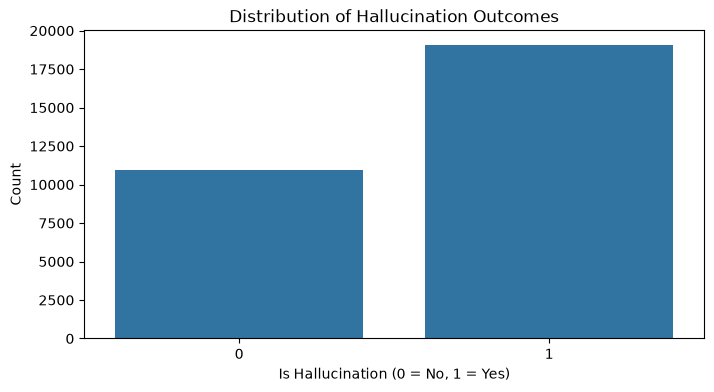

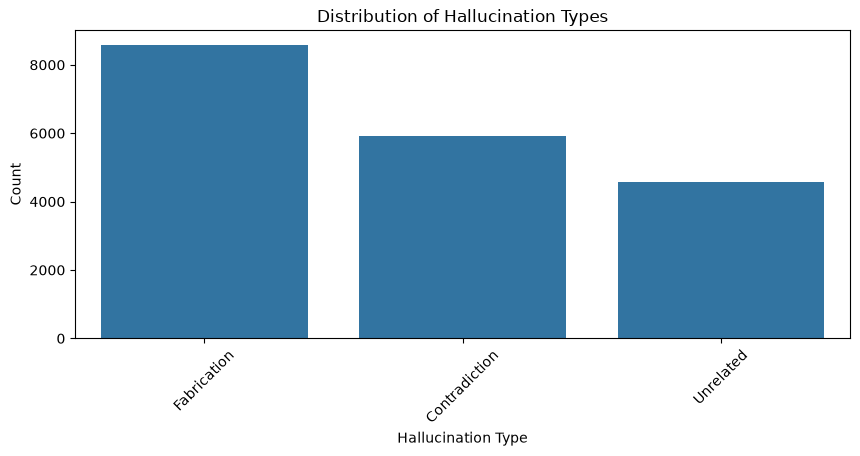

In [7]:
# Distribution of target variable: Is_Hallucination
plt.figure(figsize=(8, 4))
sns.countplot(x='Is_Hallucination', data=df)

plt.title('Distribution of Hallucination Outcomes')
plt.xlabel('Is Hallucination (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


# Distribution of Hallucination_Type
plt.figure(figsize=(10, 4))
sns.countplot(x='Hallucination_Type', data=df)

plt.title('Distribution of Hallucination Types')
plt.xlabel('Hallucination Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

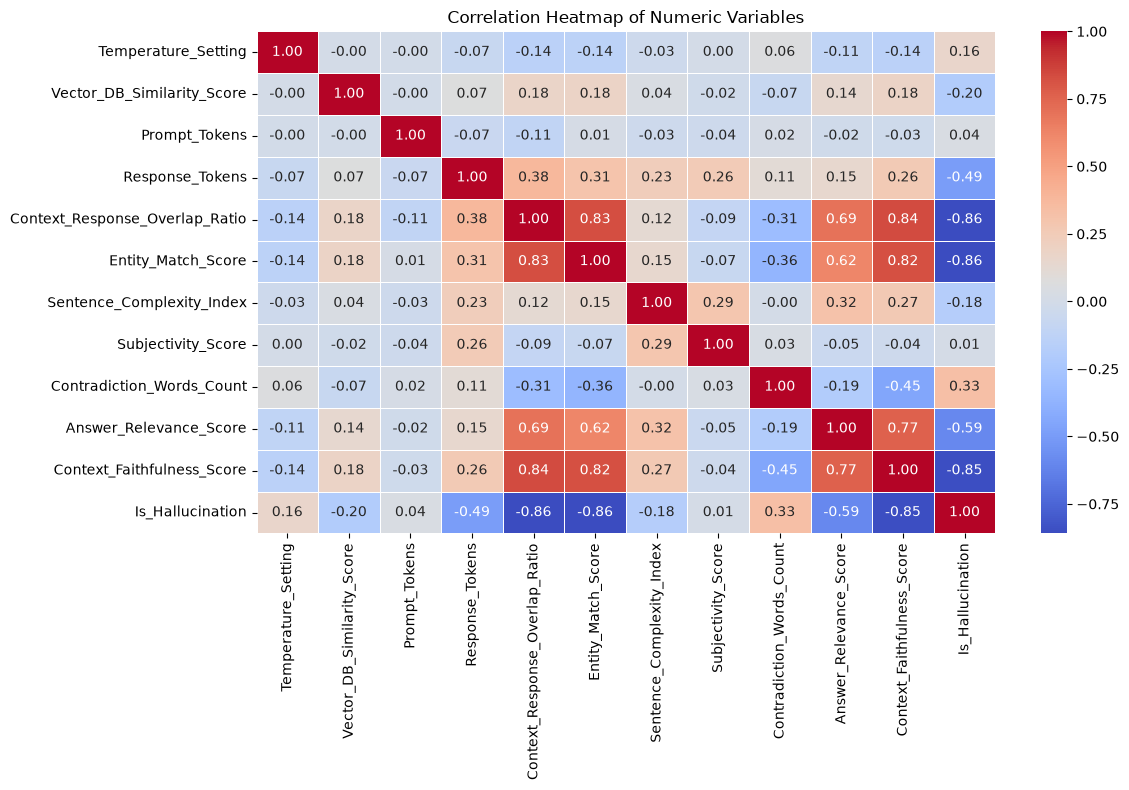

In [8]:
# Correlation heatmap of numeric variables
numeric_df = df.select_dtypes(include='number')

# Only create the heatmap if 4 or more numeric variables are present
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 8))

    correlation_matrix = numeric_df.corr()

    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap='coolwarm',
        fmt='.2f',
        linewidths=0.5
    )

    plt.title('Correlation Heatmap of Numeric Variables')
    plt.tight_layout()
    plt.show()
else:
    print(f"Only {numeric_df.shape[1]} numeric variables are present. Heatmap skipped.")

In [9]:
# Modeling and Prediction
# Target variable
target = 'Is_Hallucination'

# Select numeric columns
numeric_features = df.select_dtypes(include='number').columns.tolist()

# Remove the target from the feature list
if target in numeric_features:
    numeric_features.remove(target)

print("Numeric features available:")
print(numeric_features)

print("\nNumber of numeric features:", len(numeric_features))

Numeric features available:
['Temperature_Setting', 'Vector_DB_Similarity_Score', 'Prompt_Tokens', 'Response_Tokens', 'Context_Response_Overlap_Ratio', 'Entity_Match_Score', 'Sentence_Complexity_Index', 'Subjectivity_Score', 'Contradiction_Words_Count', 'Answer_Relevance_Score', 'Context_Faithfulness_Score']

Number of numeric features: 11


In [10]:
X = df[numeric_features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 11)
y shape: (30000,)


In [11]:
from sklearn.model_selection import train_test_split

# Features and target
X = df[numeric_features]
y = df[target]

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (24000, 11)
Testing features: (6000, 11)
Training target: (24000,)
Testing target: (6000,)


In [12]:
# Ensure our features exist in the dataframe

target = 'Is_Hallucination'

# Define the features we want to use
features = numeric_features

# Check for missing feature columns
missing_features = [col for col in features if col not in df.columns]

if missing_features:
    print("Missing features:")
    print(missing_features)
else:
    print("All selected features exist in the dataframe.")

All selected features exist in the dataframe.


In [14]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


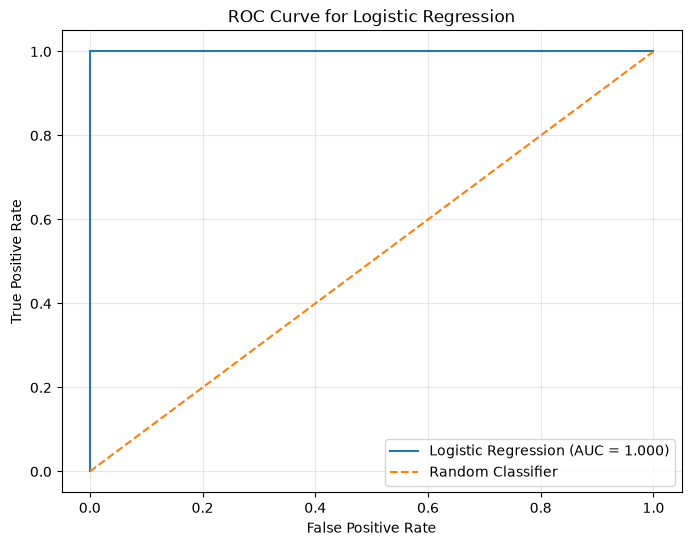

ROC-AUC Score: 1.0000


In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = log_reg.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc_score:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

In [16]:
# Check correlation of every numeric feature with the target
correlation_with_target = df[numeric_features + [target]].corr()[target].sort_values(
    ascending=False
)

print(correlation_with_target)

Is_Hallucination                  1.000000
Contradiction_Words_Count         0.332916
Temperature_Setting               0.162423
Prompt_Tokens                     0.035291
Subjectivity_Score                0.011624
Sentence_Complexity_Index        -0.177676
Vector_DB_Similarity_Score       -0.195091
Response_Tokens                  -0.491562
Answer_Relevance_Score           -0.592162
Context_Faithfulness_Score       -0.849120
Context_Response_Overlap_Ratio   -0.857396
Entity_Match_Score               -0.859369
Name: Is_Hallucination, dtype: float64


In [18]:
# Check whether any feature is identical to the target
for col in numeric_features:
    if df[col].equals(df[target]):
        print(f"Possible data leakage: {col} is identical to {target}")

In [19]:
# Compare feature averages between hallucination and non-hallucination cases

important_features = [
    'Context_Faithfulness_Score',
    'Context_Response_Overlap_Ratio',
    'Entity_Match_Score',
    'Answer_Relevance_Score',
    'Response_Tokens'
]

print(
    df.groupby('Is_Hallucination')[important_features].mean().T
)

Is_Hallucination                        0          1
Context_Faithfulness_Score       0.865413   0.306552
Context_Response_Overlap_Ratio   0.194976   0.064279
Entity_Match_Score               0.239743   0.033962
Answer_Relevance_Score           0.841034   0.543259
Response_Tokens                 15.074744  12.014746


In [20]:
print("\nTarget distribution:")
print(df['Is_Hallucination'].value_counts())

print("\nTarget percentage:")
print(df['Is_Hallucination'].value_counts(normalize=True) * 100)


Target distribution:
Is_Hallucination
1    19056
0    10944
Name: count, dtype: int64

Target percentage:
Is_Hallucination
1    63.52
0    36.48
Name: proportion, dtype: float64


In [21]:
for col in important_features:
    print(f"\n{col}")
    print(df.groupby('Is_Hallucination')[col].agg(['min', 'max', 'mean']))


Context_Faithfulness_Score
                   min   max      mean
Is_Hallucination                      
0                 0.75  0.98  0.865413
1                 0.01  0.70  0.306552

Context_Response_Overlap_Ratio
                    min    max      mean
Is_Hallucination                        
0                 0.111  0.292  0.194976
1                 0.000  0.180  0.064279

Entity_Match_Score
                    min    max      mean
Is_Hallucination                        
0                 0.077  0.333  0.239743
1                 0.000  0.231  0.033962

Answer_Relevance_Score
                   min   max      mean
Is_Hallucination                      
0                 0.70  0.98  0.841034
1                 0.05  0.90  0.543259

Response_Tokens
                  min  max       mean
Is_Hallucination                     
0                  11   21  15.074744
1                   7   22  12.014746


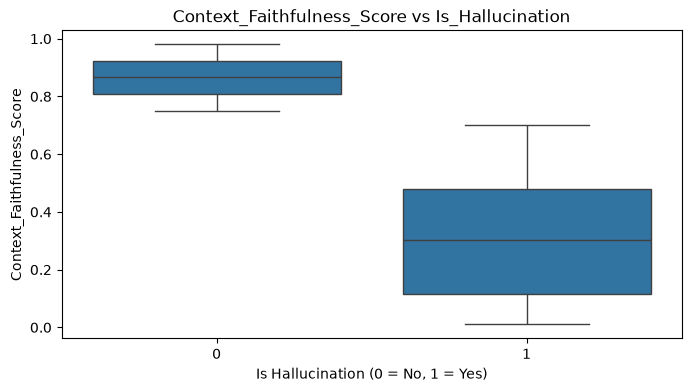

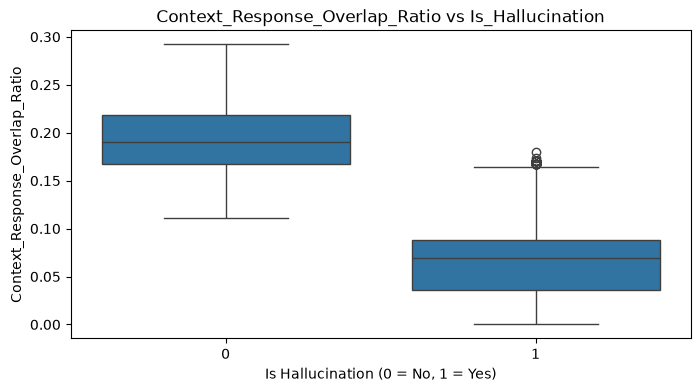

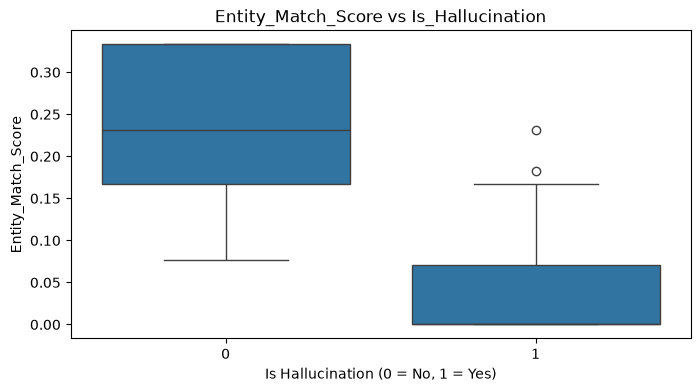

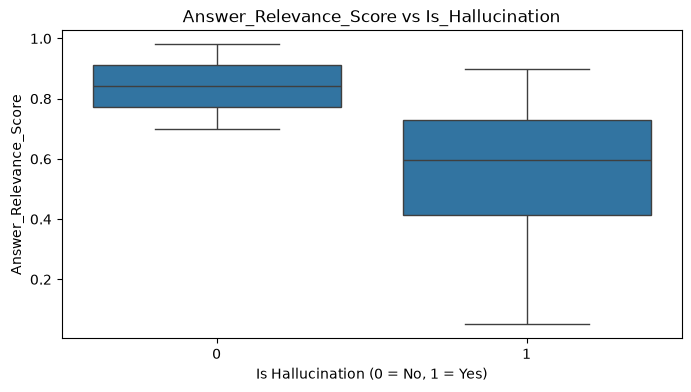

In [22]:
# Visualize important features against the target

important_features = [
    'Context_Faithfulness_Score',
    'Context_Response_Overlap_Ratio',
    'Entity_Match_Score',
    'Answer_Relevance_Score'
]

for feature in important_features:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x='Is_Hallucination',
        y=feature,
        data=df
    )

    plt.title(f'{feature} vs Is_Hallucination')
    plt.xlabel('Is Hallucination (0 = No, 1 = Yes)')
    plt.ylabel(feature)
    plt.show()

In [23]:
# Model Evaluation - Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Make predictions
y_pred = log_reg.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Performance")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression Performance
----------------------------------------
Accuracy : 0.9995
Precision: 0.9995
Recall   : 0.9997
F1-Score : 0.9996

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2189
           1       1.00      1.00      1.00      3811

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000

Confusion Matrix:
[[2187    2]
 [   1 3810]]


In [24]:
# Check whether the target can be directly derived from feature values

for feature in important_features:
    print(f"\n{'=' * 60}")
    print(feature)

    print(
        df.groupby('Is_Hallucination')[feature]
          .agg(['min', 'max', 'mean', 'std'])
    )


Context_Faithfulness_Score
                   min   max      mean       std
Is_Hallucination                                
0                 0.75  0.98  0.865413  0.066735
1                 0.01  0.70  0.306552  0.203796

Context_Response_Overlap_Ratio
                    min    max      mean       std
Is_Hallucination                                  
0                 0.111  0.292  0.194976  0.034228
1                 0.000  0.180  0.064279  0.039655

Entity_Match_Score
                    min    max      mean       std
Is_Hallucination                                  
0                 0.077  0.333  0.239743  0.077216
1                 0.000  0.231  0.033962  0.045231

Answer_Relevance_Score
                   min   max      mean       std
Is_Hallucination                                
0                 0.70  0.98  0.841034  0.080577
1                 0.05  0.90  0.543259  0.237011


In [25]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", (duplicate_count / len(df)) * 100)

Duplicate rows: 0
Duplicate percentage: 0.0


In [26]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-" * 40)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Performance
----------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC-AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2189
           1       1.00      1.00      1.00      3811

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000

Confusion Matrix:
[[2189    0]
 [   0 3811]]


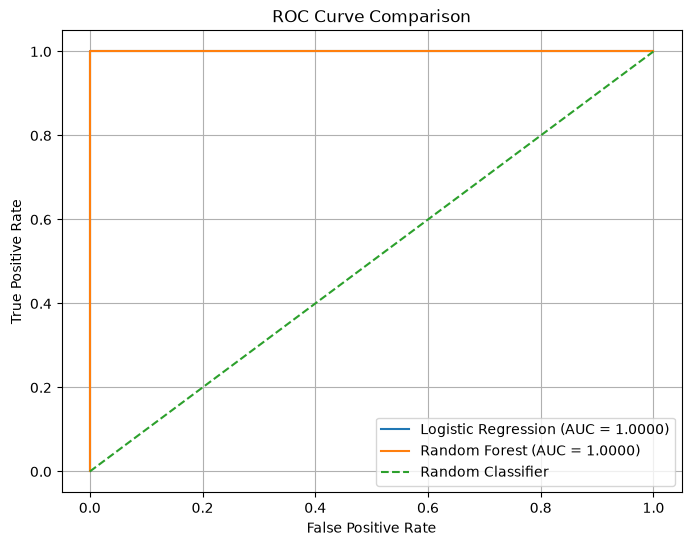

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    log_reg.predict_proba(X_test)[:, 1]
)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_model.predict_proba(X_test)[:, 1]
)

# AUC
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {auc_lr:.4f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.legend()
plt.grid(True)

# Save as SVG
plt.savefig(
    'roc_curve_comparison.svg',
    format='svg',
    bbox_inches='tight'
)

plt.show()

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Random Forest Feature Importance")
print("-" * 40)
print(feature_importance.to_string(index=False))

Random Forest Feature Importance
----------------------------------------
                       Feature  Importance
    Context_Faithfulness_Score    0.437369
            Entity_Match_Score    0.235032
Context_Response_Overlap_Ratio    0.185874
        Answer_Relevance_Score    0.087202
               Response_Tokens    0.032245
     Contradiction_Words_Count    0.016770
     Sentence_Complexity_Index    0.002982
            Subjectivity_Score    0.001094
    Vector_DB_Similarity_Score    0.001057
           Temperature_Setting    0.000248
                 Prompt_Tokens    0.000127


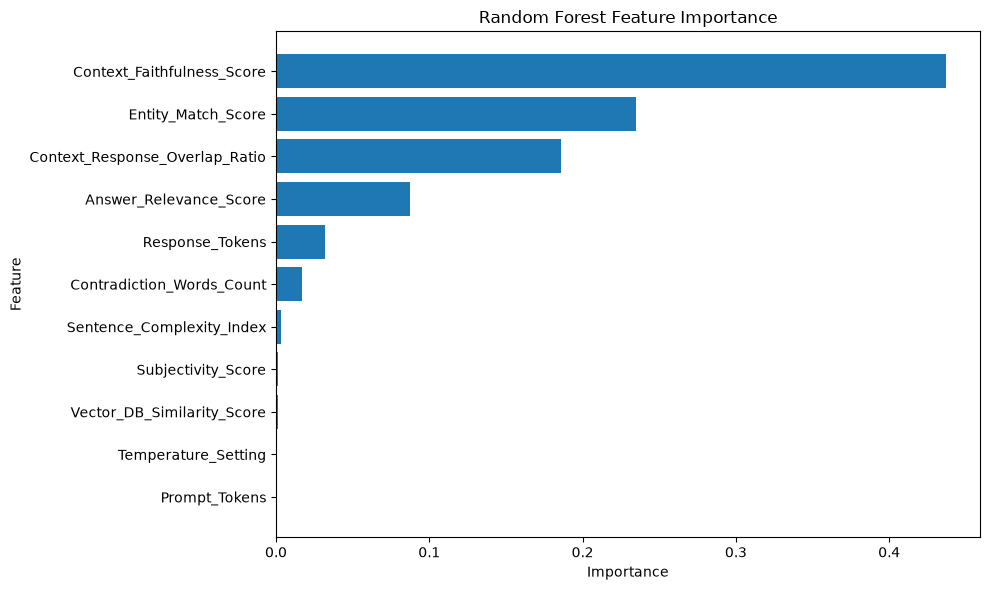

In [30]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()

plt.tight_layout()

# Save as SVG
plt.savefig(
    'random_forest_feature_importance.svg',
    format='svg',
    bbox_inches='tight'
)

plt.show()

In [31]:
# Model comparison

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, log_reg.predict(X_test)),
                 accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, log_reg.predict(X_test)),
                  precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, log_reg.predict(X_test)),
               recall_score(y_test, y_pred_rf)],
    'F1-Score': [f1_score(y_test, log_reg.predict(X_test)),
                 f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [
        roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]),
        roc_auc_rf
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9995,0.999475,0.999738,0.999606,1.0
1,Random Forest,1.0000,1.000000,1.000000,1.000000,1.0


In [36]:
# Check correlation of features with target

correlation_with_target = df[numeric_features + [target]].corr()[target] \
    .drop(target) \
    .sort_values(ascending=False)

print("Feature correlation with target:")
print(correlation_with_target)

Feature correlation with target:
Contradiction_Words_Count         0.332916
Temperature_Setting               0.162423
Prompt_Tokens                     0.035291
Subjectivity_Score                0.011624
Sentence_Complexity_Index        -0.177676
Vector_DB_Similarity_Score       -0.195091
Response_Tokens                  -0.491562
Answer_Relevance_Score           -0.592162
Context_Faithfulness_Score       -0.849120
Context_Response_Overlap_Ratio   -0.857396
Entity_Match_Score               -0.859369
Name: Is_Hallucination, dtype: float64


In [37]:
# Check feature ranges by class

for feature in numeric_features:
    print(f"\n{'=' * 60}")
    print(feature)
    
    print(
        df.groupby(target)[feature]
        .agg(['min', 'max', 'mean', 'std'])
    )


Temperature_Setting
                  min  max      mean       std
Is_Hallucination                              
0                 0.0  1.0  0.438035  0.281154
1                 0.0  1.0  0.535310  0.286364

Vector_DB_Similarity_Score
                  min  max      mean       std
Is_Hallucination                              
0                 0.0  1.0  0.574519  0.279352
1                 0.0  1.0  0.458444  0.281808

Prompt_Tokens
                  min  max       mean       std
Is_Hallucination                               
0                  81  126  93.940698  8.957924
1                  81  125  94.601280  9.031972

Response_Tokens
                  min  max       mean       std
Is_Hallucination                               
0                  11   21  15.074744  2.485944
1                   7   22  12.014746  2.678082

Context_Response_Overlap_Ratio
                    min    max      mean       std
Is_Hallucination                                  
0                 0.111  

In [38]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print("Random Forest 5-Fold Cross-Validation")
print("-" * 45)

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print("-" * 45)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Accuracy : {cv_scores.std():.4f}")

Random Forest 5-Fold Cross-Validation
---------------------------------------------
Fold 1: 1.0000
Fold 2: 1.0000
Fold 3: 1.0000
Fold 4: 1.0000
Fold 5: 1.0000
---------------------------------------------
Mean Accuracy: 1.0000
Std Accuracy : 0.0000


In [39]:

# FEATURE ABLATION TEST


strong_features = [
    "Context_Faithfulness_Score",
    "Context_Response_Overlap_Ratio",
    "Entity_Match_Score",
    "Answer_Relevance_Score"
]

ablation_features = [
    feature
    for feature in numeric_features
    if feature not in strong_features
]

print("Removed features:")
for feature in strong_features:
    print(" -", feature)

print("\nRemaining features:")
for feature in ablation_features:
    print(" -", feature)


# Prepare reduced dataset
X_train_ablation = X_train[ablation_features]
X_test_ablation = X_test[ablation_features]


# Train Random Forest without the strongest features
rf_ablation = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_ablation.fit(
    X_train_ablation,
    y_train
)


# Predictions
y_pred_ablation = rf_ablation.predict(X_test_ablation)
y_prob_ablation = rf_ablation.predict_proba(
    X_test_ablation
)[:, 1]


# Evaluation
print("\n" + "=" * 50)
print("FEATURE ABLATION RESULTS")
print("=" * 50)

print(
    f"Accuracy : "
    f"{accuracy_score(y_test, y_pred_ablation):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test, y_pred_ablation):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test, y_pred_ablation):.4f}"
)

print(
    f"F1-Score : "
    f"{f1_score(y_test, y_pred_ablation):.4f}"
)

print(
    f"ROC-AUC  : "
    f"{roc_auc_score(y_test, y_prob_ablation):.4f}"
)

Removed features:
 - Context_Faithfulness_Score
 - Context_Response_Overlap_Ratio
 - Entity_Match_Score
 - Answer_Relevance_Score

Remaining features:
 - Temperature_Setting
 - Vector_DB_Similarity_Score
 - Prompt_Tokens
 - Response_Tokens
 - Sentence_Complexity_Index
 - Subjectivity_Score
 - Contradiction_Words_Count


NameError: name 'Pipeline' is not defined

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [42]:

# FEATURE ABLATION TEST — SELF-CONTAINED


import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

RANDOM_STATE = 42

# Strongest features identified from our analysis
strong_features = [
    "Context_Faithfulness_Score",
    "Context_Response_Overlap_Ratio",
    "Entity_Match_Score",
    "Answer_Relevance_Score"
]

# Remove strongest features
ablation_features = [
    feature
    for feature in numeric_features
    if feature not in strong_features
]

print("Removed features:")
for feature in strong_features:
    print(" -", feature)

print("\nRemaining features:")
for feature in ablation_features:
    print(" -", feature)


# Prepare reduced datasets
X_train_ablation = X_train[ablation_features]
X_test_ablation = X_test[ablation_features]


# Build ablation model
rf_ablation = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])


# Train
rf_ablation.fit(
    X_train_ablation,
    y_train
)


# Predictions
y_pred_ablation = rf_ablation.predict(
    X_test_ablation
)

y_prob_ablation = rf_ablation.predict_proba(
    X_test_ablation
)[:, 1]


# Metrics
accuracy = accuracy_score(y_test, y_pred_ablation)
precision = precision_score(
    y_test,
    y_pred_ablation,
    zero_division=0
)
recall = recall_score(
    y_test,
    y_pred_ablation,
    zero_division=0
)
f1 = f1_score(
    y_test,
    y_pred_ablation,
    zero_division=0
)
roc_auc = roc_auc_score(
    y_test,
    y_prob_ablation
)


# Results
print("\n" + "=" * 55)
print("FEATURE ABLATION RESULTS")
print("=" * 55)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("=" * 55)

Removed features:
 - Context_Faithfulness_Score
 - Context_Response_Overlap_Ratio
 - Entity_Match_Score
 - Answer_Relevance_Score

Remaining features:
 - Temperature_Setting
 - Vector_DB_Similarity_Score
 - Prompt_Tokens
 - Response_Tokens
 - Sentence_Complexity_Index
 - Subjectivity_Score
 - Contradiction_Words_Count

FEATURE ABLATION RESULTS
Accuracy : 0.9782
Precision: 0.9842
Recall   : 0.9814
F1-Score : 0.9828
ROC-AUC  : 0.9972


In [43]:

# 5-FOLD CROSS-VALIDATION — ALL IMPORTANT METRICS


import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

# Pipeline


cv_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# 5-Fold Stratified CV


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    cv_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)


# Display fold results

cv_summary = pd.DataFrame({
    "Fold": np.arange(1, 6),
    "Accuracy": cv_results["test_accuracy"],
    "Precision": cv_results["test_precision"],
    "Recall": cv_results["test_recall"],
    "F1-Score": cv_results["test_f1"],
    "ROC-AUC": cv_results["test_roc_auc"]
})

print("=" * 65)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 65)

display(cv_summary.round(4))

print("\n" + "=" * 65)
print("MEAN ± STD")
print("=" * 65)

for metric in scoring:
    values = cv_results[f"test_{metric}"]
    print(
        f"{metric.upper():10s}: "
        f"{values.mean():.4f} ± {values.std():.4f}"
    )

5-FOLD CROSS-VALIDATION RESULTS


,Fold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,1.0,1.0,1.0,1.0,1.0
1,2,1.0,1.0,1.0,1.0,1.0
2,3,1.0,1.0,1.0,1.0,1.0
3,4,1.0,1.0,1.0,1.0,1.0
4,5,1.0,1.0,1.0,1.0,1.0



MEAN ± STD
ACCURACY  : 1.0000 ± 0.0000
PRECISION : 1.0000 ± 0.0000
RECALL    : 1.0000 ± 0.0000
F1        : 1.0000 ± 0.0000
ROC_AUC   : 1.0000 ± 0.0000


In [45]:

# DATA LEAKAGE check gareko


import pandas as pd
import numpy as np

TARGET = "Is_Hallucination"

print("=" * 70)
print("DATA LEAKAGE AUDIT")
print("=" * 70)


#  TARGET DISTRIBUTION


print("\n[1] TARGET DISTRIBUTION")
print("-" * 70)

target_counts = df[TARGET].value_counts().sort_index()
target_percent = df[TARGET].value_counts(normalize=True).sort_index() * 100

for cls in target_counts.index:
    print(
        f"Class {cls}: "
        f"{target_counts[cls]:,} samples "
        f"({target_percent[cls]:.2f}%)"
    )

#  EXACT DUPLICATE ROWS


print("\n[2] DUPLICATE ROW CHECK")
print("-" * 70)

duplicate_count = int(df.duplicated().sum())

print(f"Duplicate rows: {duplicate_count:,}")

if duplicate_count == 0:
    print("PASS: No exact duplicate rows found.")
else:
    print("WARNING: Duplicate rows detected.")


#  MISSING VALUES


print("\n[3] MISSING VALUE CHECK")
print("-" * 70)

missing = df[numeric_features + [TARGET]].isnull().sum()

missing_total = int(missing.sum())

print(f"Total missing values: {missing_total:,}")

if missing_total == 0:
    print("PASS: No missing values found.")
else:
    display(missing[missing > 0])



#  CLASS-CONDITIONAL FEATURE CHECK


print("\n[4] CLASS-CONDITIONAL FEATURE CHECK")
print("-" * 70)

for feature in numeric_features:

    class_unique = df.groupby(TARGET)[feature].nunique()

    if (class_unique <= 1).any():

        print(f"\nFeature: {feature}")
        print("Unique values per class:")
        print(class_unique.to_dict())



#  FEATURE RANGE / SEPARATION CHECK


print("\n[5] FEATURE SEPARATION CHECK")
print("-" * 70)

separation_results = []

for feature in numeric_features:

    class_0 = df.loc[df[TARGET] == 0, feature]
    class_1 = df.loc[df[TARGET] == 1, feature]

    min_0 = class_0.min()
    max_0 = class_0.max()

    min_1 = class_1.min()
    max_1 = class_1.max()

    perfect_separation = (
        max_0 < min_1 or
        max_1 < min_0
    )

    separation_results.append({
        "Feature": feature,
        "Class_0_Min": min_0,
        "Class_0_Max": max_0,
        "Class_1_Min": min_1,
        "Class_1_Max": max_1,
        "Perfect_Separation": perfect_separation
    })

separation_df = pd.DataFrame(separation_results)

display(separation_df)



# FEATURE-TARGET CORRELATION


print("\n[6] FEATURE-TARGET CORRELATION")
print("-" * 70)

correlations = (
    df[numeric_features + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)

correlation_df = correlations.rename(
    "Absolute_Correlation"
).to_frame()

display(correlation_df)


# TRAIN / TEST OVERLAP

print("\n[7] TRAIN / TEST FEATURE OVERLAP")
print("-" * 70)

overlap_results = []

for feature in numeric_features:

    train_values = set(
        X_train[feature].dropna().unique()
    )

    test_values = set(
        X_test[feature].dropna().unique()
    )

    shared_values = train_values.intersection(test_values)

    overlap_results.append({
        "Feature": feature,
        "Train_Unique": len(train_values),
        "Test_Unique": len(test_values),
        "Shared_Values": len(shared_values)
    })

overlap_df = pd.DataFrame(overlap_results)

display(overlap_df)
#  PERFECTLY SEPARATING FEATURES

print("\n[8] PERFECTLY SEPARATING FEATURES")
print("-" * 70)

perfect_features = separation_df.loc[
    separation_df["Perfect_Separation"] == True,
    "Feature"
].tolist()

if len(perfect_features) == 0:

    print("None found.")

else:

    print("Features requiring investigation:")

    for feature in perfect_features:
        print(f" - {feature}")
# FINAL SUMMARY


print("\n" + "=" * 70)
print("LEAKAGE AUDIT SUMMARY")
print("=" * 70)

print(f"Total rows              : {len(df):,}")
print(f"Duplicate rows          : {duplicate_count:,}")
print(f"Missing values          : {missing_total:,}")
print(
    f"Perfectly separating features: "
    f"{len(perfect_features)}"
)

print("\nNOTE:")
print("Strong feature separation does not automatically mean leakage.")
print("Feature-generation methodology must also be checked.")

print("=" * 70)

DATA LEAKAGE AUDIT

[1] TARGET DISTRIBUTION
----------------------------------------------------------------------
Class 0: 10,944 samples (36.48%)
Class 1: 19,056 samples (63.52%)

[2] DUPLICATE ROW CHECK
----------------------------------------------------------------------
Duplicate rows: 0
PASS: No exact duplicate rows found.

[3] MISSING VALUE CHECK
----------------------------------------------------------------------
Total missing values: 0
PASS: No missing values found.

[4] CLASS-CONDITIONAL FEATURE CHECK
----------------------------------------------------------------------

Feature: Contradiction_Words_Count
Unique values per class:
{0: 1, 1: 2}

[5] FEATURE SEPARATION CHECK
----------------------------------------------------------------------


,Feature,Class_0_Min,Class_0_Max,Class_1_Min,Class_1_Max,Perfect_Separation
0,Temperature_Setting,0.000,1.000,0.000,1.000,False
1,Vector_DB_Similarity_Score,0.000,1.000,0.000,1.000,False
2,Prompt_Tokens,81.000,126.000,81.000,125.000,False
3,Response_Tokens,11.000,21.000,7.000,22.000,False
4,Context_Response_Overlap_Ratio,0.111,0.292,0.000,0.180,False
5,Entity_Match_Score,0.077,0.333,0.000,0.231,False
6,Sentence_Complexity_Index,0.223,0.667,0.133,0.600,False
7,Subjectivity_Score,0.000,1.000,0.000,1.000,False
8,Contradiction_Words_Count,0.000,0.000,0.000,1.000,False
9,Answer_Relevance_Score,0.700,0.980,0.050,0.900,False



[6] FEATURE-TARGET CORRELATION
----------------------------------------------------------------------


,Absolute_Correlation
Entity_Match_Score,0.859369
Context_Response_Overlap_Ratio,0.857396
Context_Faithfulness_Score,0.849120
Answer_Relevance_Score,0.592162
Response_Tokens,0.491562
Contradiction_Words_Count,0.332916
Vector_DB_Similarity_Score,0.195091
Sentence_Complexity_Index,0.177676
Temperature_Setting,0.162423
Prompt_Tokens,0.035291



[7] TRAIN / TEST FEATURE OVERLAP
----------------------------------------------------------------------


,Feature,Train_Unique,Test_Unique,Shared_Values
0,Temperature_Setting,101,101,101
1,Vector_DB_Similarity_Score,1001,998,998
2,Prompt_Tokens,35,34,34
3,Response_Tokens,12,12,12
4,Context_Response_Overlap_Ratio,205,190,190
5,Entity_Match_Score,25,24,24
6,Sentence_Complexity_Index,118,112,112
7,Subjectivity_Score,51,41,41
8,Contradiction_Words_Count,2,2,2
9,Answer_Relevance_Score,832,823,823



[8] PERFECTLY SEPARATING FEATURES
----------------------------------------------------------------------
Features requiring investigation:
 - Context_Faithfulness_Score

LEAKAGE AUDIT SUMMARY
Total rows              : 30,000
Duplicate rows          : 0
Missing values          : 0
Perfectly separating features: 1

NOTE:
Strong feature separation does not automatically mean leakage.
Feature-generation methodology must also be checked.


In [46]:
# Remove all RAG-quality / potentially target-derived features

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Features that may be directly related to answer quality


suspicious_features = [
    "Context_Faithfulness_Score",
    "Context_Response_Overlap_Ratio",
    "Entity_Match_Score",
    "Answer_Relevance_Score",
    "Contradiction_Words_Count"
]

strict_features = [
    feature
    for feature in numeric_features
    if feature not in suspicious_features
]

print("=" * 70)
print("STRICT FEATURE ABLATION")
print("=" * 70)

print("\nRemoved features:")
for feature in suspicious_features:
    print(f" - {feature}")

print("\nRemaining features:")
for feature in strict_features:
    print(f" - {feature}")



# Prepare data


X_strict = df[strict_features]
y_strict = df[TARGET]

X_train_strict, X_test_strict, y_train_strict, y_test_strict = train_test_split(
    X_strict,
    y_strict,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_strict
)


# Model


strict_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])


# Train


strict_model.fit(
    X_train_strict,
    y_train_strict
)


# Evaluate


y_pred_strict = strict_model.predict(X_test_strict)
y_prob_strict = strict_model.predict_proba(X_test_strict)[:, 1]

accuracy = accuracy_score(y_test_strict, y_pred_strict)
precision = precision_score(y_test_strict, y_pred_strict)
recall = recall_score(y_test_strict, y_pred_strict)
f1 = f1_score(y_test_strict, y_pred_strict)
roc_auc = roc_auc_score(y_test_strict, y_prob_strict)

# Results


print("\n" + "=" * 70)
print("STRICT ABLATION RESULTS")
print("=" * 70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("=" * 70)

STRICT FEATURE ABLATION

Removed features:
 - Context_Faithfulness_Score
 - Context_Response_Overlap_Ratio
 - Entity_Match_Score
 - Answer_Relevance_Score
 - Contradiction_Words_Count

Remaining features:
 - Temperature_Setting
 - Vector_DB_Similarity_Score
 - Prompt_Tokens
 - Response_Tokens
 - Sentence_Complexity_Index
 - Subjectivity_Score

STRICT ABLATION RESULTS
Accuracy : 0.9622
Precision: 0.9681
Recall   : 0.9724
F1-Score : 0.9703
ROC-AUC  : 0.9922


In [47]:

# FINAL RAG HALLUCINATION DETECTOR
import joblib
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42
TARGET = "Is_Hallucination"


# FINAL FEATURES


final_features = [
    "Temperature_Setting",
    "Vector_DB_Similarity_Score",
    "Prompt_Tokens",
    "Response_Tokens",
    "Sentence_Complexity_Index",
    "Subjectivity_Score"
]

print("=" * 70)
print("FINAL MODEL FEATURES")
print("=" * 70)

for feature in final_features:
    print(f" - {feature}")


X_final = df[final_features]
y_final = df[TARGET]


# Train/Test Split


from sklearn.model_selection import train_test_split

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_final
)


# Final Random Forest Pipeline

final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),

    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])


# Train
final_model.fit(
    X_train_final,
    y_train_final
)

# Predictions


y_pred_final = final_model.predict(X_test_final)

y_prob_final = final_model.predict_proba(
    X_test_final
)[:, 1]


# Metrics


accuracy = accuracy_score(
    y_test_final,
    y_pred_final
)

precision = precision_score(
    y_test_final,
    y_pred_final
)

recall = recall_score(
    y_test_final,
    y_pred_final
)

f1 = f1_score(
    y_test_final,
    y_pred_final
)

roc_auc = roc_auc_score(
    y_test_final,
    y_prob_final
)

# Results

print("FINAL MODEL PERFORMANCE")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# Classification Report

print("CLASSIFICATION REPORT")

print(
    classification_report(
        y_test_final,
        y_pred_final,
        target_names=[
            "No Hallucination",
            "Hallucination"
        ],
        digits=4
    )
)


# Confusion Matrix

cm = confusion_matrix(
    y_test_final,
    y_pred_final
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)

# Save Model


joblib.dump(
    final_model,
    "rag_hallucination_detector.pkl"
)

joblib.dump(
    final_features,
    "rag_hallucination_features.pkl"
)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print("rag_hallucination_detector.pkl")
print("rag_hallucination_features.pkl")

FINAL MODEL FEATURES
 - Temperature_Setting
 - Vector_DB_Similarity_Score
 - Prompt_Tokens
 - Response_Tokens
 - Sentence_Complexity_Index
 - Subjectivity_Score
FINAL MODEL PERFORMANCE
Accuracy : 0.9622
Precision: 0.9681
Recall   : 0.9724
F1-Score : 0.9703
ROC-AUC  : 0.9922
CLASSIFICATION REPORT
                  precision    recall  f1-score   support

No Hallucination     0.9517    0.9443    0.9479      2189
   Hallucination     0.9681    0.9724    0.9703      3811

        accuracy                         0.9622      6000
       macro avg     0.9599    0.9584    0.9591      6000
    weighted avg     0.9621    0.9622    0.9621      6000


CONFUSION MATRIX
[[2067  122]
 [ 105 3706]]

MODEL SAVED
rag_hallucination_detector.pkl
rag_hallucination_features.pkl


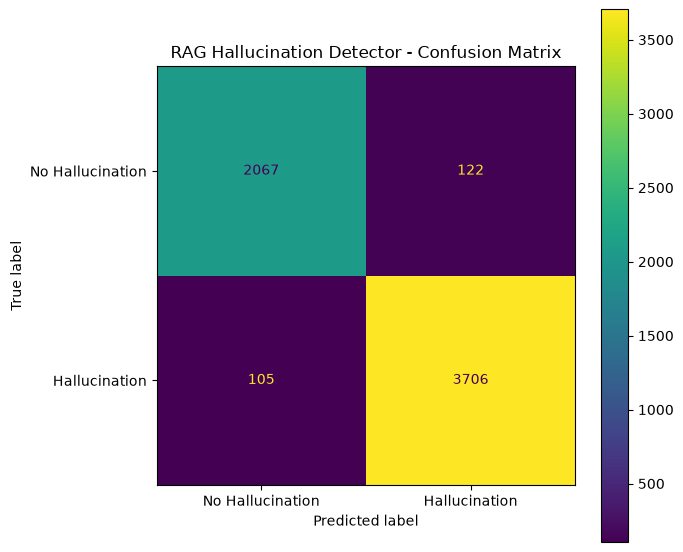

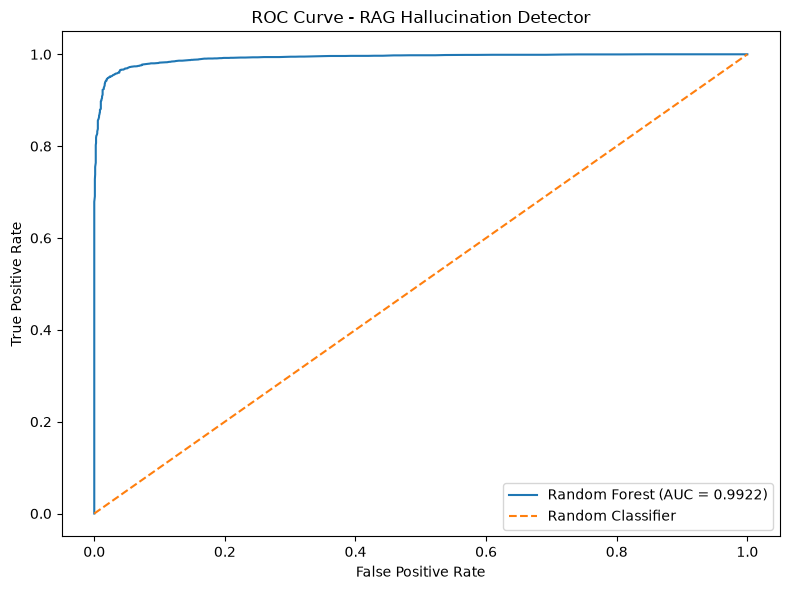

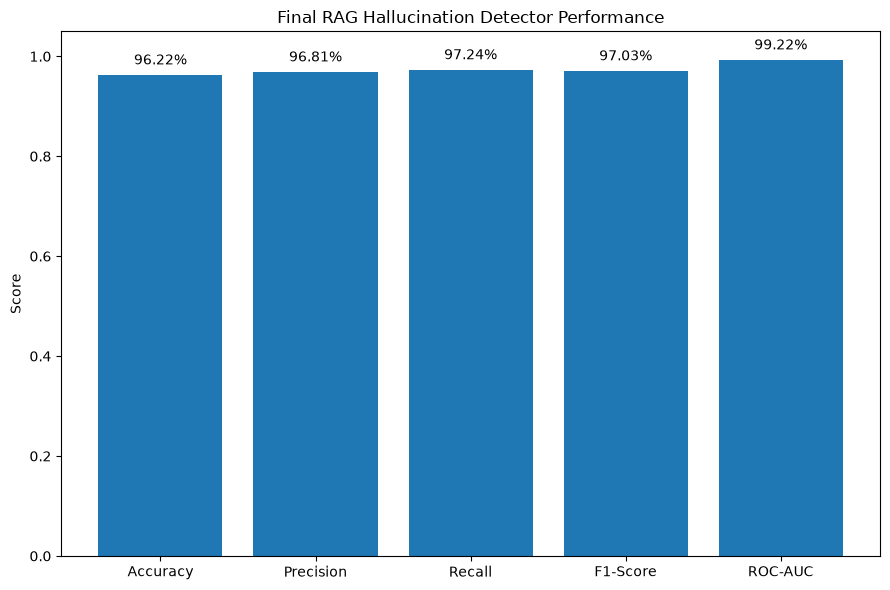

In [49]:
# FINAL MODEL VISUALIZATIONS

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)


#  CONFUSION MATRIX


fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Hallucination", "Hallucination"]
).plot(
    ax=ax,
    values_format="d"
)

ax.set_title("RAG Hallucination Detector - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "final_confusion_matrix.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()


#  ROC CURVE


fpr, tpr, thresholds = roc_curve(
    y_test_final,
    y_prob_final
)

roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc_value:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RAG Hallucination Detector")
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    "final_roc_curve.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()


#  FINAL METRICS BAR CHART


metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

plt.figure(figsize=(9, 6))

bars = plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1.05)

plt.ylabel("Score")
plt.title("Final RAG Hallucination Detector Performance")

for bar, value in zip(bars, metrics.values()):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.2%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "final_model_metrics.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()


#SAVE FINAL RESULTS


results_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results_df.to_csv(
    "final_model_results.csv",
    index=False
)




In [50]:

# PRODUCTION PREDICTION FUNCTION

import joblib
import pandas as pd

# Load trained model


loaded_model = joblib.load(
    "rag_hallucination_detector.pkl"
)

loaded_features = joblib.load(
    "rag_hallucination_features.pkl"
)

# Prediction function


def predict_hallucination(
    temperature,
    vector_db_similarity,
    prompt_tokens,
    response_tokens,
    sentence_complexity,
    subjectivity
):

    input_data = {
        "Temperature_Setting": temperature,
        "Vector_DB_Similarity_Score": vector_db_similarity,
        "Prompt_Tokens": prompt_tokens,
        "Response_Tokens": response_tokens,
        "Sentence_Complexity_Index": sentence_complexity,
        "Subjectivity_Score": subjectivity
    }

    input_df = pd.DataFrame([input_data])

    # Ensure exact training feature order
    input_df = input_df[loaded_features]

    # Prediction
    prediction = loaded_model.predict(input_df)[0]

    # Probability
    probability = loaded_model.predict_proba(input_df)[0][1]

    # Label
    if prediction == 1:
        label = "Hallucination"
    else:
        label = "No Hallucination"

    return {
        "prediction": int(prediction),
        "label": label,
        "hallucination_probability": round(
            float(probability),
            4
        ),
        "confidence": round(
            float(max(probability, 1 - probability)),
            4
        )
    }


print("Prediction function loaded successfully.")

Prediction function loaded successfully.


In [51]:

# TEST 1 — LIKELY NON-HALLUCINATION


result = predict_hallucination(
    temperature=0.2,
    vector_db_similarity=0.85,
    prompt_tokens=100,
    response_tokens=18,
    sentence_complexity=0.40,
    subjectivity=0.20
)

print(result)

{'prediction': 0, 'label': 'No Hallucination', 'hallucination_probability': 0.1533, 'confidence': 0.8467}


In [52]:

# TEST 2 — LIKELY HALLUCINATI# 
result = predict_hallucination(
    temperature=0.9,
    vector_db_similarity=0.25,
    prompt_tokens=100,
    response_tokens=9,
    sentence_complexity=0.25,
    subjectivity=0.70
)

print(result)

{'prediction': 1, 'label': 'Hallucination', 'hallucination_probability': 0.91, 'confidence': 0.91}


In [53]:
result = predict_hallucination(
    temperature=0.2,
    vector_db_similarity=0.85,
    prompt_tokens=100,
    response_tokens=18,
    sentence_complexity=0.40,
    subjectivity=0.20
)

print(result)

{'prediction': 0, 'label': 'No Hallucination', 'hallucination_probability': 0.1533, 'confidence': 0.8467}
